#  Bayesian Transformer for Reinforcement Learning

In [1]:
import os, sys, json
from copy import deepcopy
from datetime import datetime as dt
from ruamel.yaml import YAML
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch

from torch.nn import functional as F

In [2]:
from TRL.common.utils import init_env,  env_reset, env_step, one_hot_encode
from TRL.networks.transition import Network as TransitionNetwork

/home/shamail/torch2_cuda12_env/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn


In [3]:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
display = pd.options.display
display.max_rows = 1000

In [4]:
model_details = pd.DataFrame(columns=['env','lr','context_len','hidden_dims','num_params',
                                      'data_samples','train_epochs',
                                      'avg_loss'])

In [5]:
config = "configs/config_vector_env3-setting1.yaml"
with open(config, "r") as f:
    yaml = YAML(typ='rt')
    config = yaml.load(f)

config["experiment"]["name"] += '-transition_test'
config['gpu'] = False
config['transition']['context_length'] = 3
config['experiment']['env'] = '5'
config['transition']['heads'] = 2
config['experiment']['deterministic'] = False
config['experiment']

{'suite': 'bsuite', 'env': '5', 'test': True, 'deterministic': False, 'steps': 10000.0, 'time_limit': 300, 'test_freq': 100.0, 'name': '-transition_test', 'seed': 'None'}

In [6]:
env, possible_actions, test_env, obs_space = init_env(
    config["experiment"]["suite"], config["experiment"]["env"], test=False, 
    deterministic=config['experiment']['deterministic']
)
possible_actions = torch.tensor(possible_actions, dtype=int).reshape(len(possible_actions),-1)

_deterministic: False
deterministic False


/home/shamail/torch2_cuda12_env/lib/python3.10/site-packages/bsuite/environments/deep_sea.py:84: UserWarning: Environment is in debug mode (randomize_actions=False).Only randomized_actions=True is the DeepSea environment.
  warnings.warn('Environment is in debug mode (randomize_actions=False).'


In [7]:
config['transition']

{'training_iterations': 20, 'hidden_dim': 32, 'learning_rate': 0.01, 'window_length': 3, 'context_length': 3, 'num_encoder_layers': 2, 'heads': 2, 'forward_expansion': 4}

In [8]:
time_limit=1000
time_limit

1000

In [9]:
torch.tensor(range(config['transition']['context_length']))

tensor([0, 1, 2])

In [10]:
def generate_transition_data(config, num_transitions=100):
    env, possible_actions, test_env, obs_space = init_env(
    config["experiment"]["suite"], config["experiment"]["env"], test=False, 
    deterministic=True
    )
    transitions = []
    test_transitions = {}
    state = env_reset(env, config["experiment"]["suite"])
    episodes = {
            "states": [None]*num_transitions,
            "actions": [],
            "next_states": [],
            "rewards": [],
            "terminals": [],
            "timestep": [None]*num_transitions
        }

    timestep = 0
    trajectory = np.zeros((config['transition']['context_length'], obs_space)).tolist()
    ts = np.zeros((config['transition']['context_length']),dtype=int).tolist()
    # print('init trajectory',trajectory)
    for i in range(num_transitions):
        action = env.action_space.sample()  # Random action
        next_state, reward, done = env_step(env, config['experiment']['suite'],  action)
#         print('\ntimestep:',timestep,
#               '\tstate:',state.tolist().index(1),
#               '\taction:',action,
#               '\tnext_state:',next_state.tolist().index(1) if sum(next_state) else '0',
#               '\tReward:',round(reward,4),'\tdone:',done)

#         print('\nstate:',state)
        # print('next_state',next_state)
        trajectory.append(state.tolist())
        trajectory.pop(0)
        ts.append(timestep)
        ts.pop(0)
        # print('trajectory:',trajectory)
        episodes['states'][i] = deepcopy(trajectory)
        episodes['next_states'].append(next_state.tolist())
        episodes['actions'].append(action)
        episodes['rewards'].append(reward)
        episodes['timestep'][i] = deepcopy(ts)
        episodes['terminals'].append(done)
        
        if not done:
            s = state.tolist().index(1)
            next_s_idx = next_state.tolist().index(1) if sum(next_state) else 0
            if s not in test_transitions:
                test_transitions[s] = {
                    'trajectory':deepcopy(trajectory),
                    'timestep':deepcopy(ts),
                    'next_state':[None]*len(possible_actions)
                }
                test_transitions[s]['next_state'][action] = next_s_idx
            else:
                if next_s_idx not in test_transitions[s]['next_state']:
                     test_transitions[s]['next_state'][action] = next_s_idx
        
        if done:
            state = env_reset(env, config["experiment"]["suite"])
            trajectory = np.zeros((config['transition']['context_length'], obs_space)).tolist()
            timestep = 0
            ts = np.zeros((config['transition']['context_length']),dtype=int).tolist()
        else:
            state = next_state
            timestep += 1
   
        
    return episodes, test_transitions


In [11]:
episodes, test_transitions = generate_transition_data(config, time_limit)

_deterministic: True
deterministic True


In [12]:
test_transitions.keys()

dict_keys([0, 6, 12, 16, 10, 15, 5, 11, 17, 18])

In [13]:
test_size=len(test_transitions.keys())*len(possible_actions)
test_size

20

In [14]:
s_idx = list(test_transitions.keys())
s_idx.sort()
test_transitions = {i: test_transitions[i] for i in s_idx}
test_transitions.keys()

dict_keys([0, 5, 6, 10, 11, 12, 15, 16, 17, 18])

In [15]:
test_transitions.keys()

dict_keys([0, 5, 6, 10, 11, 12, 15, 16, 17, 18])

In [16]:
len(test_transitions[0]['trajectory'][0])

25

In [17]:
print(config['transition'])
def test_model(model, test_transitions):
    iterations = 100
    obs_space = len(test_transitions[0]['trajectory'][0])
    test_state_ids = test_transitions.keys()
    true_next = deepcopy(test_transitions)
    for i in test_state_ids:
        true_next[i] = test_transitions[i]['next_state']
        
    pred = {i:{0:[],1:[]} for i in test_state_ids}
    for _ in range(iterations):
        for i in test_state_ids:
            # adding batch dimension
            observation = torch.tensor(test_transitions[i]['trajectory'],dtype=torch.float32).unsqueeze(0)
            # adding current_state as a batch for each action
            observation = torch.cat([observation for _ in possible_actions],dim=0)
            
            t = torch.tensor(test_transitions[i]['timestep'],dtype=int).unsqueeze(0)
            ts = torch.cat([t for _ in possible_actions], dim=0)   
            
            pred_next_states, pred_rewards = model.predict(ts, observation, possible_actions)            
            pred_next_states = torch.argmax(pred_next_states,1).squeeze()
#             print('\ncurrent state:',i,'\tactions:',possible_actions,'\tpred next_state:',pred_next_states,'\n')
            idx = np.argmax(observation[0].numpy(),-1)[-1]
            
            pred[idx][0].append(pred_next_states[0].item())
            pred[idx][1].append(pred_next_states[1].item())
            
            t = torch.tensor(range(1,config['transition']['context_length']+1),dtype=int)
    
    data = []
    for i,state_idx in enumerate(test_state_ids):    
        for a in possible_actions:
            result = {}
            result['current_state'] = state_idx
            result['action'] = a.item()
            next_state = true_next[state_idx][a.item()] if true_next[state_idx][a.item()] else obs_space-1
            result['true next_state'] = next_state
            
            result['pred next_state'] = np.round(np.mean(pred[state_idx][a.item()],0))
            result['variance'] = np.round(np.var(pred[state_idx][a.item()],0),4)
            data.append(result)
    data = pd.DataFrame(data)

    return data



{'training_iterations': 20, 'hidden_dim': 32, 'learning_rate': 0.01, 'window_length': 3, 'context_length': 3, 'num_encoder_layers': 2, 'heads': 2, 'forward_expansion': 4}


In [18]:
states = torch.tensor(episodes['states'])
next_states = torch.tensor(episodes['next_states'])
timesteps = torch.tensor(episodes['timestep'], dtype=int)
rewards = torch.tensor(episodes['rewards']).unsqueeze(1)
actions = torch.tensor(episodes['actions'], dtype=int).unsqueeze(1)

In [19]:
timesteps.shape, timesteps[:3]

(torch.Size([1000, 3]),
 tensor([[0, 0, 0],
         [0, 0, 1],
         [0, 1, 2]]))

In [20]:
states.shape, states[:3]

(torch.Size([1000, 3, 25]),
 tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0.],
          [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0.]],
 
         [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0.],
          [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0.]],
 
         [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
           0., 0., 0., 0.,

In [21]:
learning_rate = 1e-3
num_epochs = 100
config["transition"]

{'training_iterations': 20, 'hidden_dim': 32, 'learning_rate': 0.01, 'window_length': 3, 'context_length': 3, 'num_encoder_layers': 2, 'heads': 2, 'forward_expansion': 4}

In [22]:
# learning_rate = 1e-3
config["transition"]["hidden_dim"] = 8
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run2 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run2.append(loss.item())

print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))

performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance

/home/shamail/torch2_cuda12_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Number of parameters: 2674
Correct preds: 2 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,11.0,39.3516
1,0,1,6,11.0,41.5075
2,5,0,10,13.0,39.8964
3,5,1,11,13.0,45.2924
4,6,0,10,12.0,45.9900
5,6,1,12,14.0,44.0384
6,10,0,15,13.0,49.9891
7,10,1,16,14.0,51.5500
8,11,0,15,15.0,49.1099
9,11,1,17,15.0,53.5044


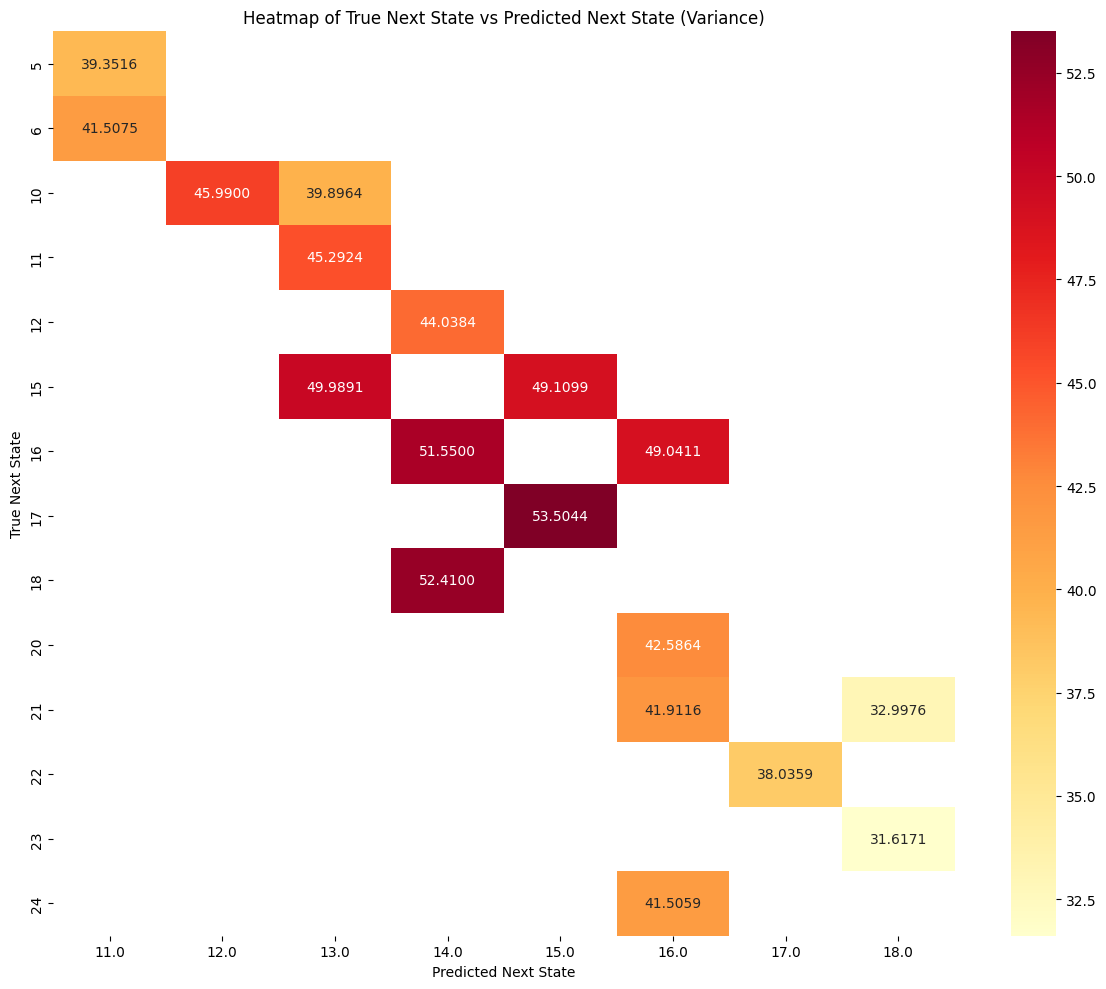

In [23]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [24]:
# learning_rate = 1e-3
config["transition"]["hidden_dim"] = 16
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run3 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run3.append(loss.item())

print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))

performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 9354
Correct preds: 2 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,8.0,8.9979
1,0,1,6,6.0,0.0291
2,5,0,10,10.0,15.2896
3,5,1,11,7.0,7.2264
4,6,0,10,9.0,10.4339
5,6,1,12,7.0,7.1400
6,10,0,15,11.0,16.1600
7,10,1,16,9.0,32.9699
8,11,0,15,10.0,5.5579
9,11,1,17,8.0,18.1216


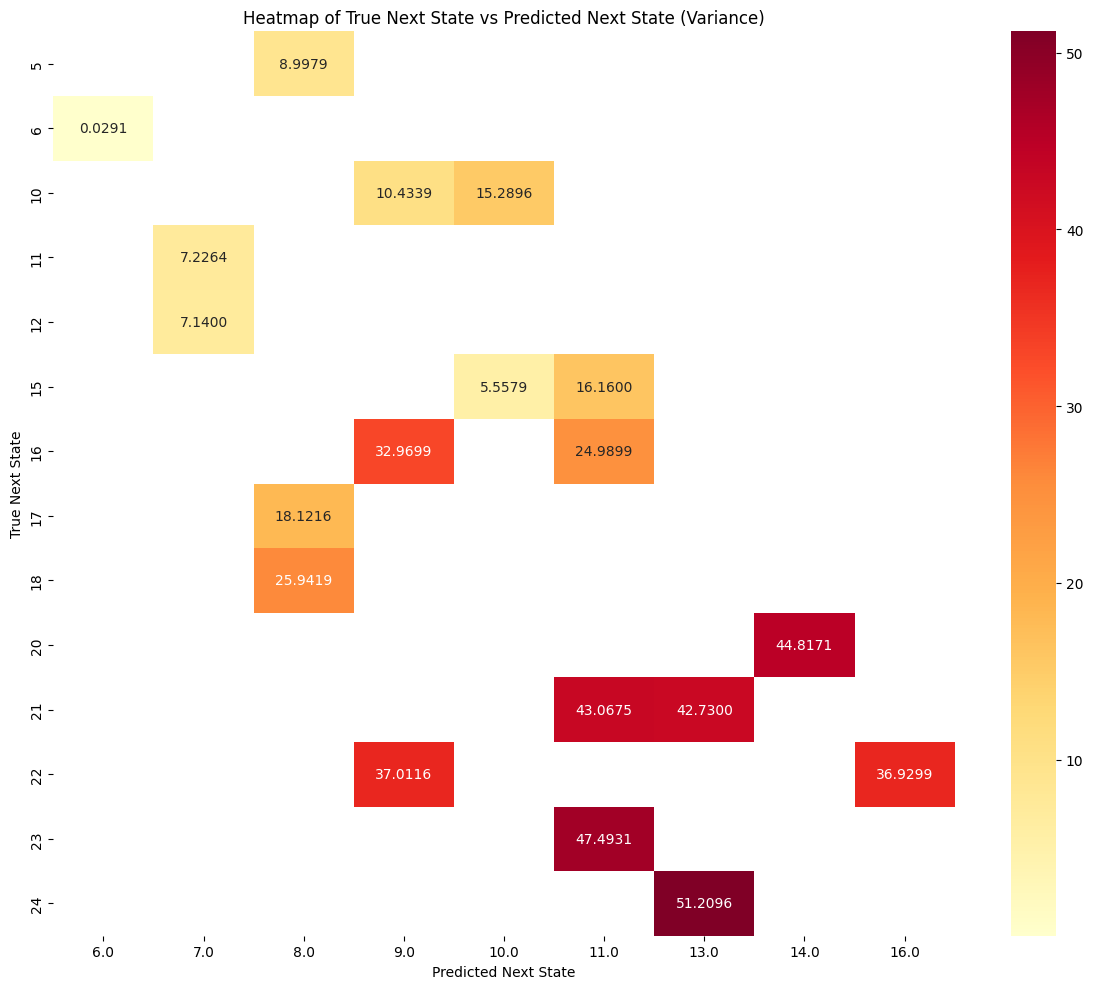

In [25]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [26]:
# learning_rate = 1e-3
config["transition"]["hidden_dim"] = 32
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run4 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run4.append(loss.item())

print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))

performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 34810
Correct preds: 8 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,3.1275
1,0,1,6,6.0,0.0196
2,5,0,10,10.0,2.2475
3,5,1,11,10.0,11.0456
4,6,0,10,10.0,1.7475
5,6,1,12,11.0,13.9024
6,10,0,15,15.0,6.5475
7,10,1,16,15.0,8.0044
8,11,0,15,15.0,3.5475
9,11,1,17,14.0,12.6371


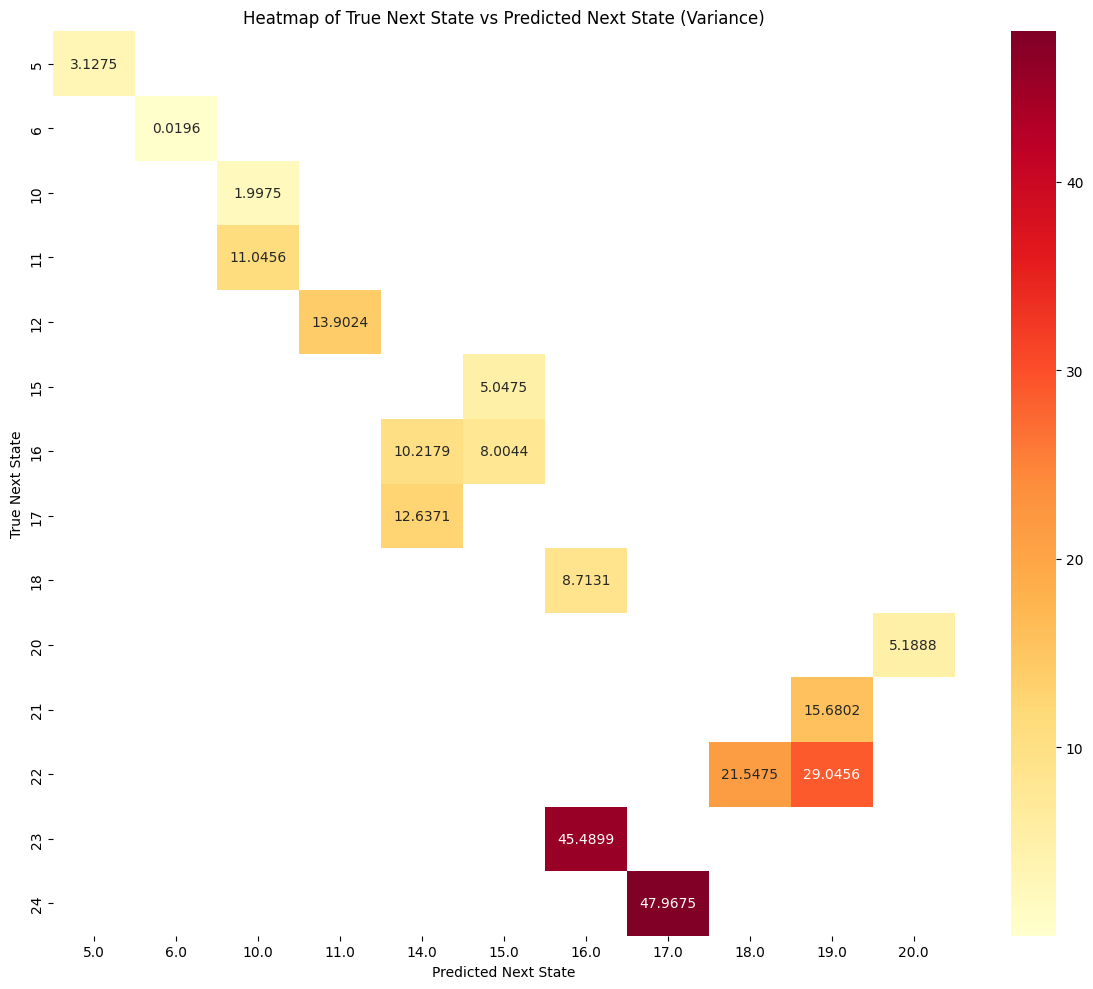

In [27]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [28]:
print(f"\nAvg Train Loss: {sum(total_loss_run4) / num_epochs}")
print('Final state_loss:',state_loss.item(),'\treward_loss:',reward_loss.item())
actual_next_s_idx = torch.argmax(next_states,1).squeeze()
predicted_next_s_idx = torch.argmax(predicted_next_states,1)
print('STATE RMSE',(torch.sum(
    (actual_next_s_idx-predicted_next_s_idx)**2)/len(next_states)
)**0.5)

data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run4)
}])
model_details = pd.concat([model_details,data], ignore_index=True)
# model_details


Avg Train Loss: 0.04610777029767633
Final state_loss: 0.023260921239852905 	reward_loss: 0.0028262219857424498
STATE RMSE tensor(5.5639)


/tmp/ipykernel_78323/1722788380.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_details = pd.concat([model_details,data], ignore_index=True)


In [29]:
# learning_rate = 1e-3
config["transition"]["hidden_dim"] = 64
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run5 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run5.append(loss.item())

print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))

performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 134106
Correct preds: 12 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,0.0000
1,0,1,6,6.0,0.0000
2,5,0,10,10.0,0.0000
3,5,1,11,11.0,0.7404
4,6,0,10,10.0,0.7275
5,6,1,12,11.0,0.2331
6,10,0,15,15.0,0.0099
7,10,1,16,16.0,0.0000
8,11,0,15,15.0,0.9900
9,11,1,17,16.0,2.3404


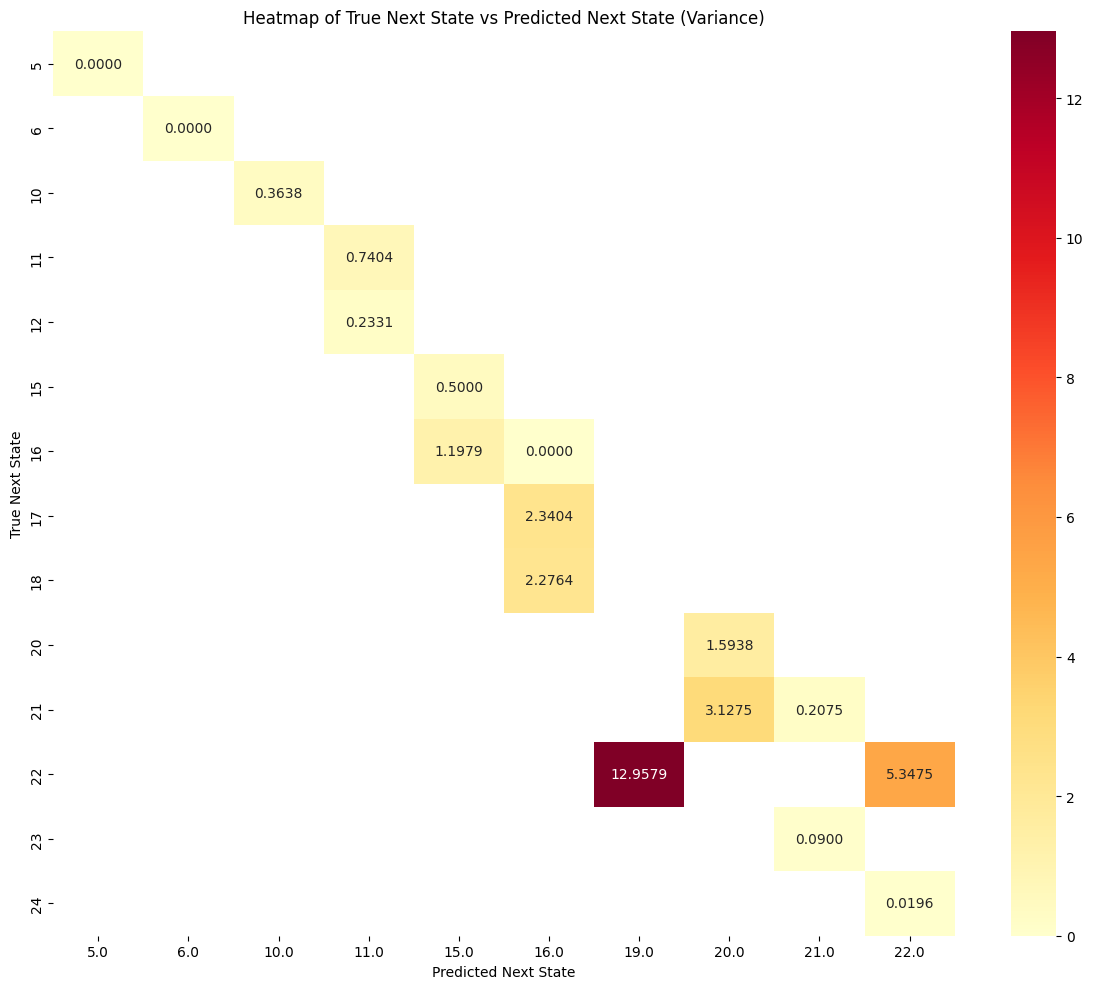

In [30]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [31]:
print(f"\nAvg Train Loss: {sum(total_loss_run5) / num_epochs}")
print('Final state_loss:',state_loss.item(),'\treward_loss:',reward_loss.item())
actual_next_s_idx = torch.argmax(next_states,1).squeeze()
predicted_next_s_idx = torch.argmax(predicted_next_states,1)
print('STATE RMSE',(torch.sum(
    (actual_next_s_idx-predicted_next_s_idx)**2)/len(next_states)
)**0.5)

data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run5)
}])
model_details = pd.concat([model_details,data], ignore_index=True)
# model_details


Avg Train Loss: 0.03948954549618065
Final state_loss: 0.013003358617424965 	reward_loss: 0.0023365120869129896
STATE RMSE tensor(6.9053)


In [32]:
learning_rate = 1e-3
config["transition"]["hidden_dim"] = 128
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run6 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run6.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))

performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 526234
Correct preds: 14 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,0.0000
1,0,1,6,6.0,0.0000
2,5,0,10,10.0,0.2475
3,5,1,11,11.0,0.8475
4,6,0,10,10.0,0.2475
5,6,1,12,12.0,0.7600
6,10,0,15,15.0,0.0000
7,10,1,16,16.0,0.0000
8,11,0,15,15.0,0.0000
9,11,1,17,15.0,6.7776


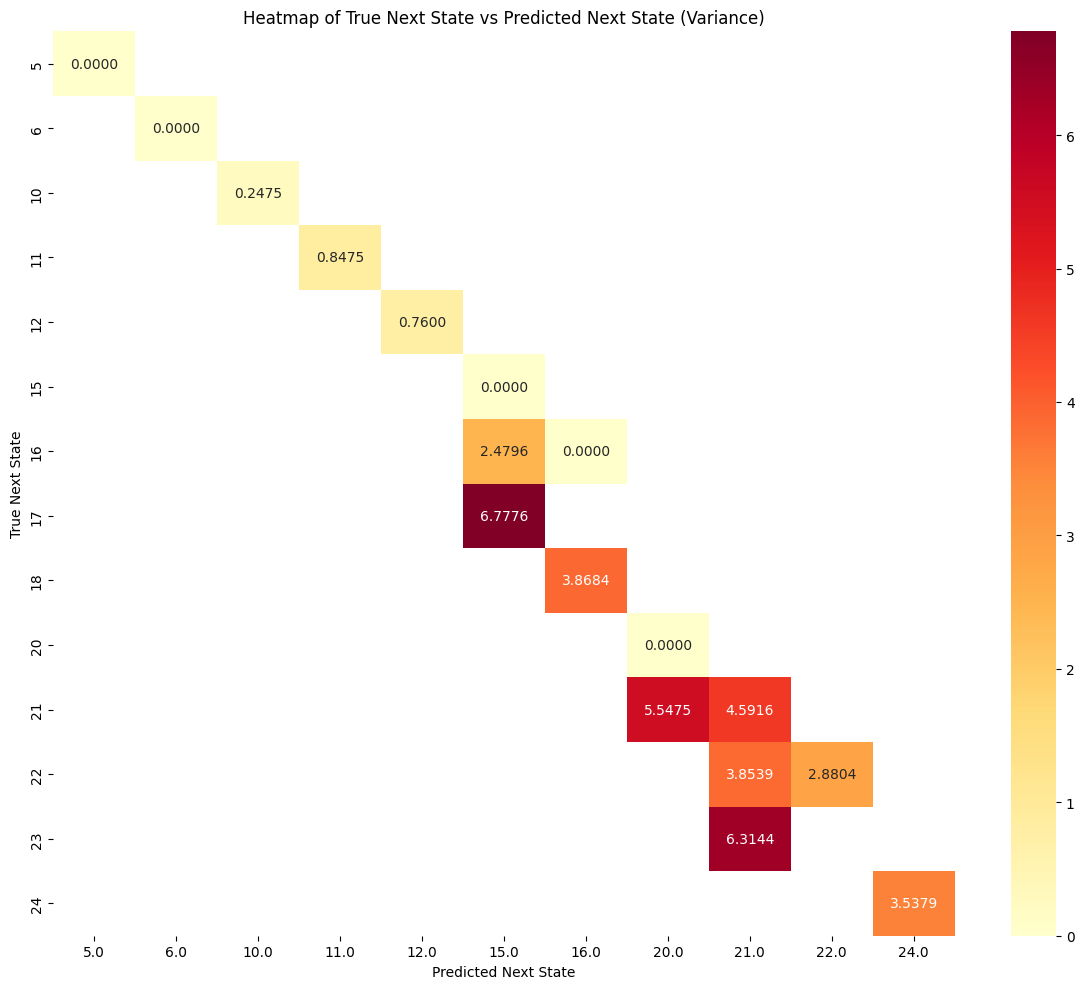

In [33]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [34]:
print(f"\nAvg Train Loss: {sum(total_loss_run6) / num_epochs}")
print('Final state_loss:',state_loss.item(),'\treward_loss:',reward_loss.item())
actual_next_s_idx = torch.argmax(next_states,1).squeeze()
predicted_next_s_idx = torch.argmax(predicted_next_states,1)
print('STATE RMSE',(torch.sum(
    (actual_next_s_idx-predicted_next_s_idx)**2)/len(next_states)
)**0.5)

data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run6)
}])
model_details = pd.concat([model_details,data], ignore_index=True)
model_details


Avg Train Loss: 0.03485832415521145
Final state_loss: 0.009510817006230354 	reward_loss: 0.0034341588616371155
STATE RMSE tensor(7.3802)


,env,lr,context_len,hidden_dims,num_params,data_samples,train_epochs,avg_loss,best_loss
0,5,0.001,3,32,34810,1000,100,NaN,0.026087
1,5,0.001,3,64,134106,1000,100,NaN,0.015340
2,5,0.001,3,128,526234,1000,100,NaN,0.010887


In [35]:
learning_rate = 1e-3
config["transition"]["hidden_dim"] = 256
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run7 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run7.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))

performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 2084634
Correct preds: 14 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,0.4900
1,0,1,6,6.0,0.0000
2,5,0,10,10.0,0.2475
3,5,1,11,11.0,0.5691
4,6,0,10,10.0,0.0000
5,6,1,12,12.0,1.1331
6,10,0,15,15.0,0.0000
7,10,1,16,16.0,0.1900
8,11,0,15,15.0,0.0000
9,11,1,17,16.0,1.4491


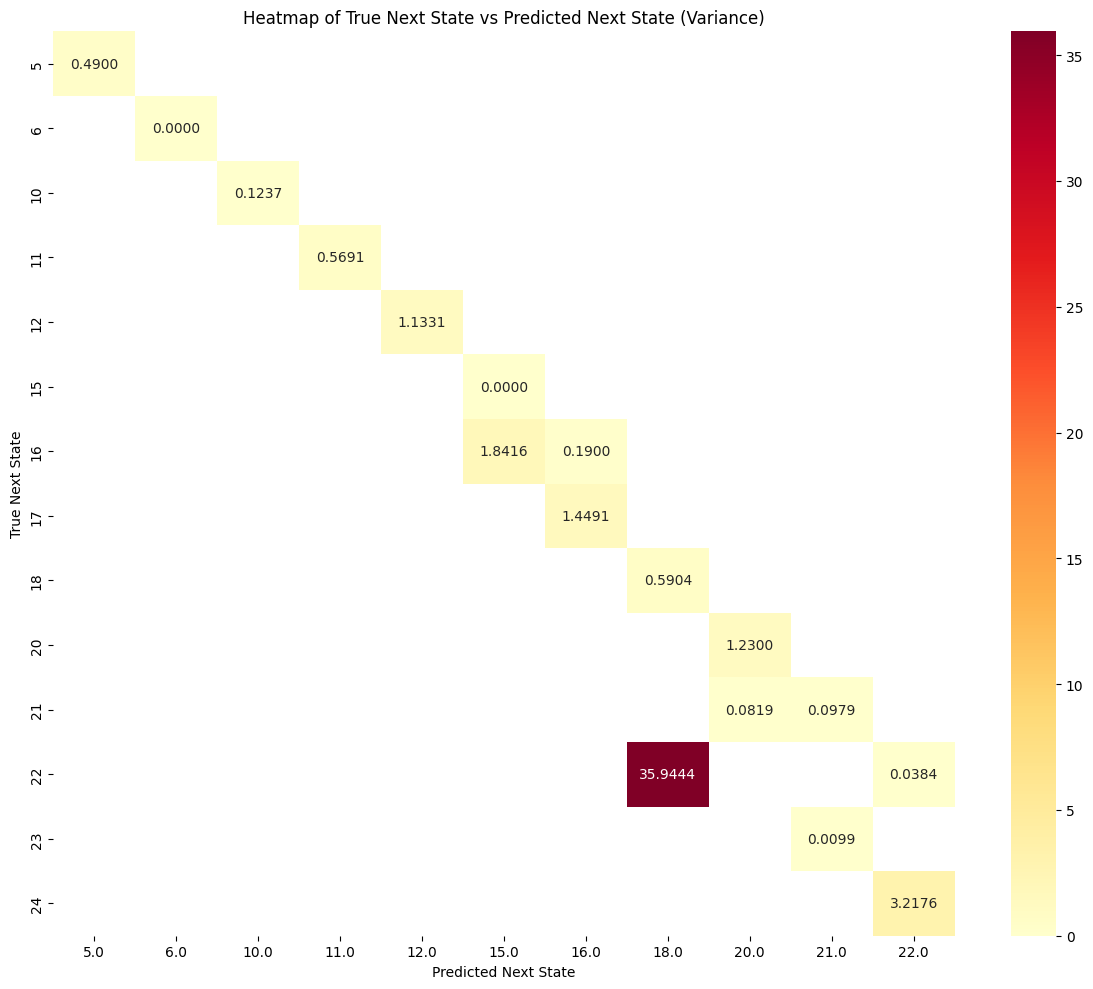

In [36]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [37]:
learning_rate = 1e-3
config["transition"]["hidden_dim"] = 512
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run8 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run8.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))

performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 8298010
Correct preds: 1 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,9.0,5.0400
1,0,1,6,6.0,0.0000
2,5,0,10,9.0,4.4275
3,5,1,11,6.0,0.0000
4,6,0,10,9.0,3.8475
5,6,1,12,6.0,0.0000
6,10,0,15,9.0,4.4275
7,10,1,16,6.0,0.0000
8,11,0,15,9.0,4.6875
9,11,1,17,6.0,0.0000


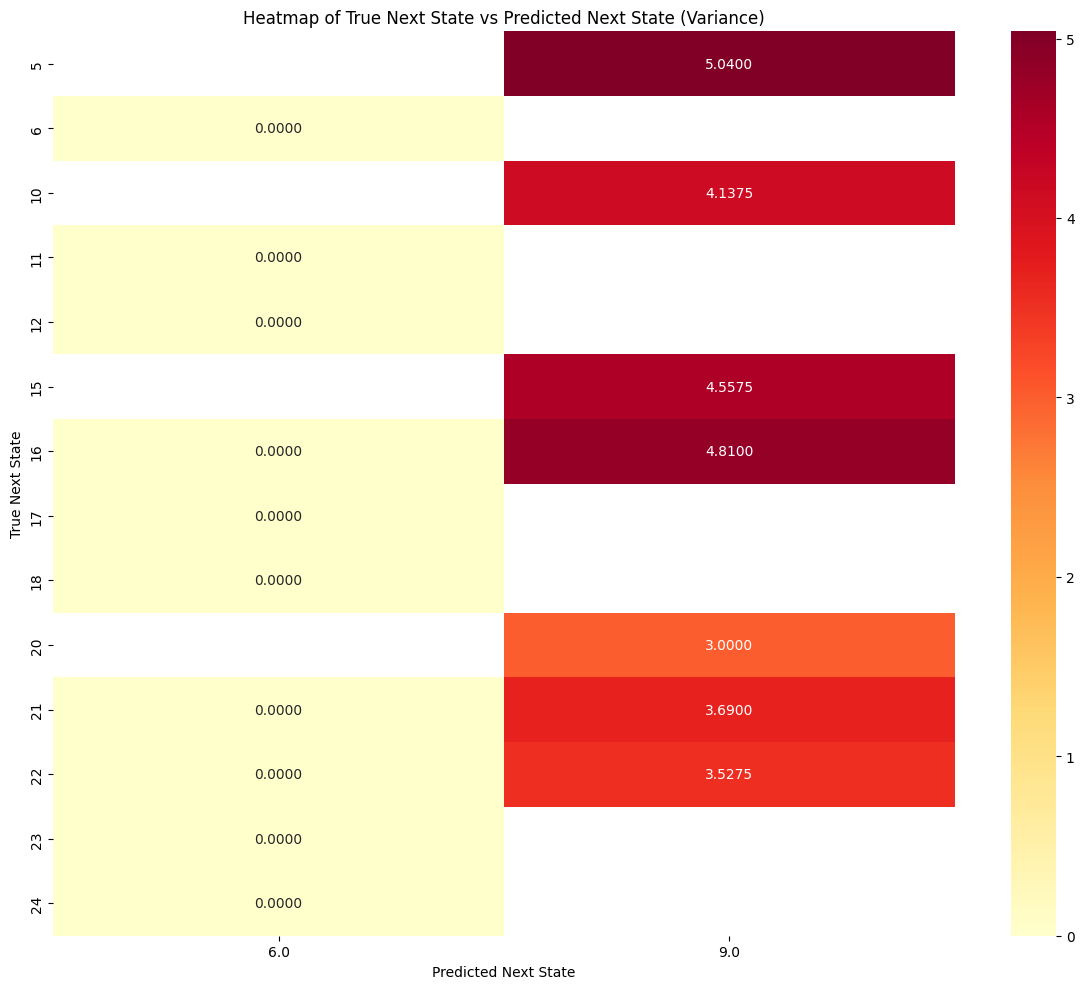

In [38]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

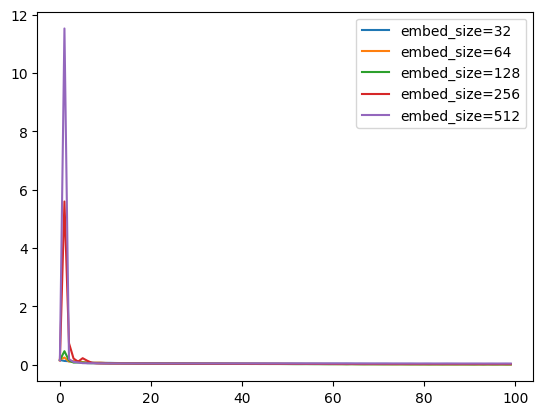

In [39]:

plt.plot(range(num_epochs), total_loss_run4, label='embed_size=32')
plt.plot(range(num_epochs), total_loss_run5, label='embed_size=64')
plt.plot(range(num_epochs), total_loss_run6, label='embed_size=128')
plt.plot(range(num_epochs), total_loss_run7, label='embed_size=256')
plt.plot(range(num_epochs), total_loss_run8, label='embed_size=512')
plt.legend()
# learning_rate = 1e-3

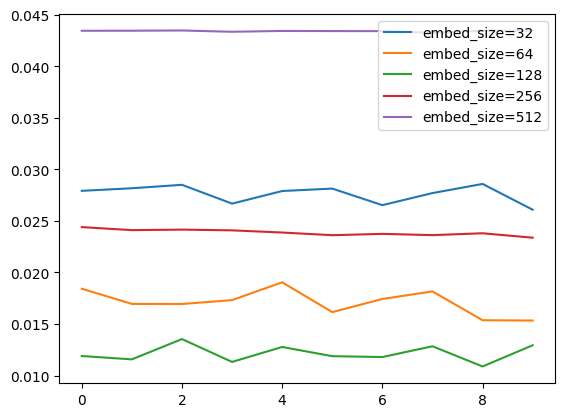

In [40]:
# zooming into the last 10 epochs
plt.plot(range(10), total_loss_run4[-10:], label='embed_size=32')
plt.plot(range(10), total_loss_run5[-10:], label='embed_size=64')
plt.plot(range(10), total_loss_run6[-10:], label='embed_size=128')
plt.plot(range(10), total_loss_run7[-10:], label='embed_size=256')
plt.plot(range(10), total_loss_run8[-10:], label='embed_size=512')
plt.legend()

In [41]:
learning_rate = 1e-4

In [42]:
# lr: 1e-4
config["transition"]["hidden_dim"] = 32
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run4 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run4.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))
performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 34810
Correct preds: 1 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,12.0,34.5411
1,0,1,6,11.0,26.9516
2,5,0,10,12.0,21.0979
3,5,1,11,11.0,20.2996
4,6,0,10,12.0,22.3824
5,6,1,12,10.0,25.3484
6,10,0,15,12.0,24.9956
7,10,1,16,12.0,27.6144
8,11,0,15,13.0,28.6019
9,11,1,17,11.0,35.2875


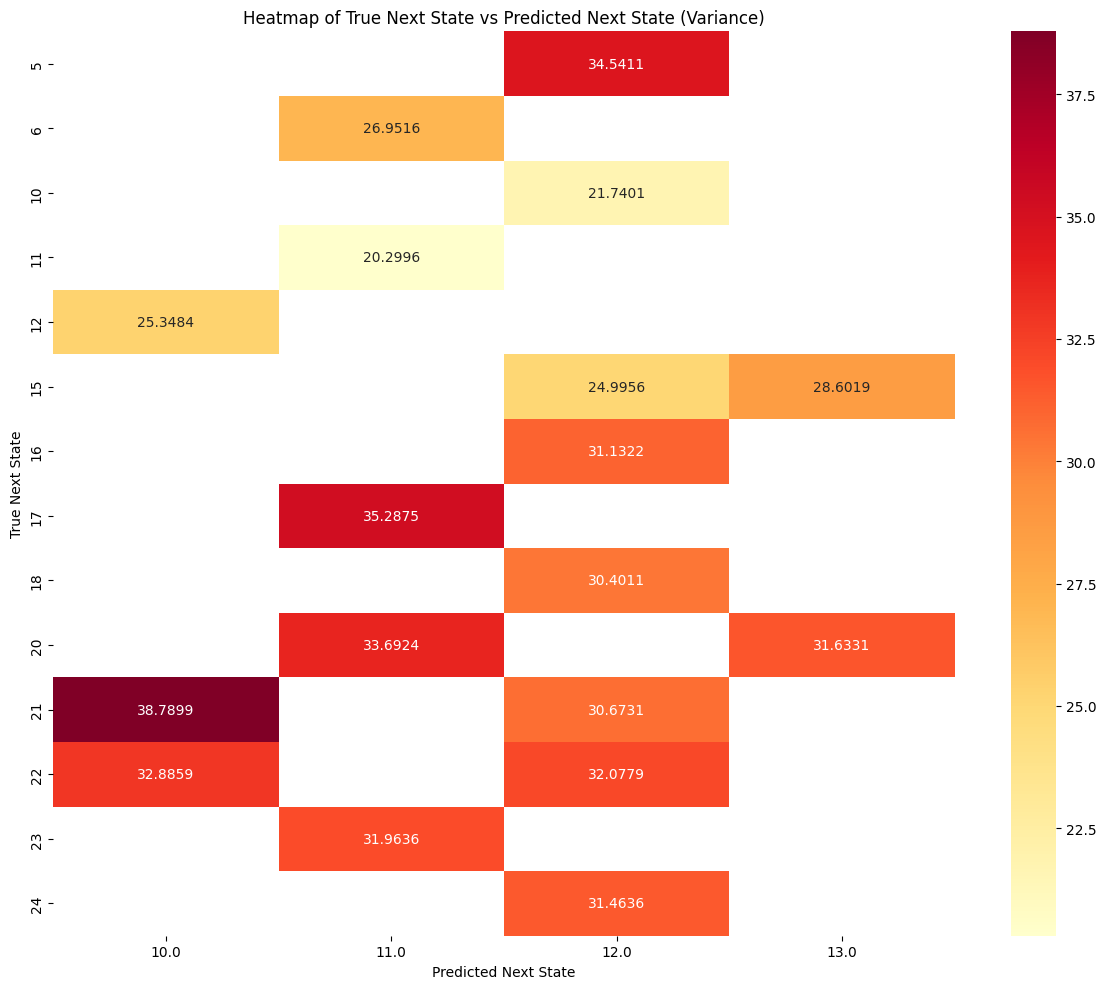

In [43]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [44]:
print(f"\nAvg Train Loss: {sum(total_loss_run4) / num_epochs}")
print('Final state_loss:',state_loss.item(),'\treward_loss:',reward_loss.item())
actual_next_s_idx = torch.argmax(next_states,1).squeeze()
predicted_next_s_idx = torch.argmax(predicted_next_states,1)
print('STATE RMSE',(torch.sum(
    (actual_next_s_idx-predicted_next_s_idx)**2)/len(next_states)
)**0.5)

data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run4)
}])
model_details = pd.concat([model_details,data], ignore_index=True)
# model_details


Avg Train Loss: 0.11823754474520683
Final state_loss: 0.046231769025325775 	reward_loss: 0.02349739335477352
STATE RMSE tensor(9.5231)


In [45]:
# lr: 1e-4
config["transition"]["hidden_dim"] = 64
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run5 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run5.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))
performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 134106
Correct preds: 2 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,10.0,24.7804
1,0,1,6,11.0,29.0000
2,5,0,10,10.0,15.8244
3,5,1,11,12.0,20.3376
4,6,0,10,10.0,11.0211
5,6,1,12,11.0,20.8699
6,10,0,15,11.0,15.4075
7,10,1,16,12.0,22.5331
8,11,0,15,12.0,18.5536
9,11,1,17,14.0,12.7619


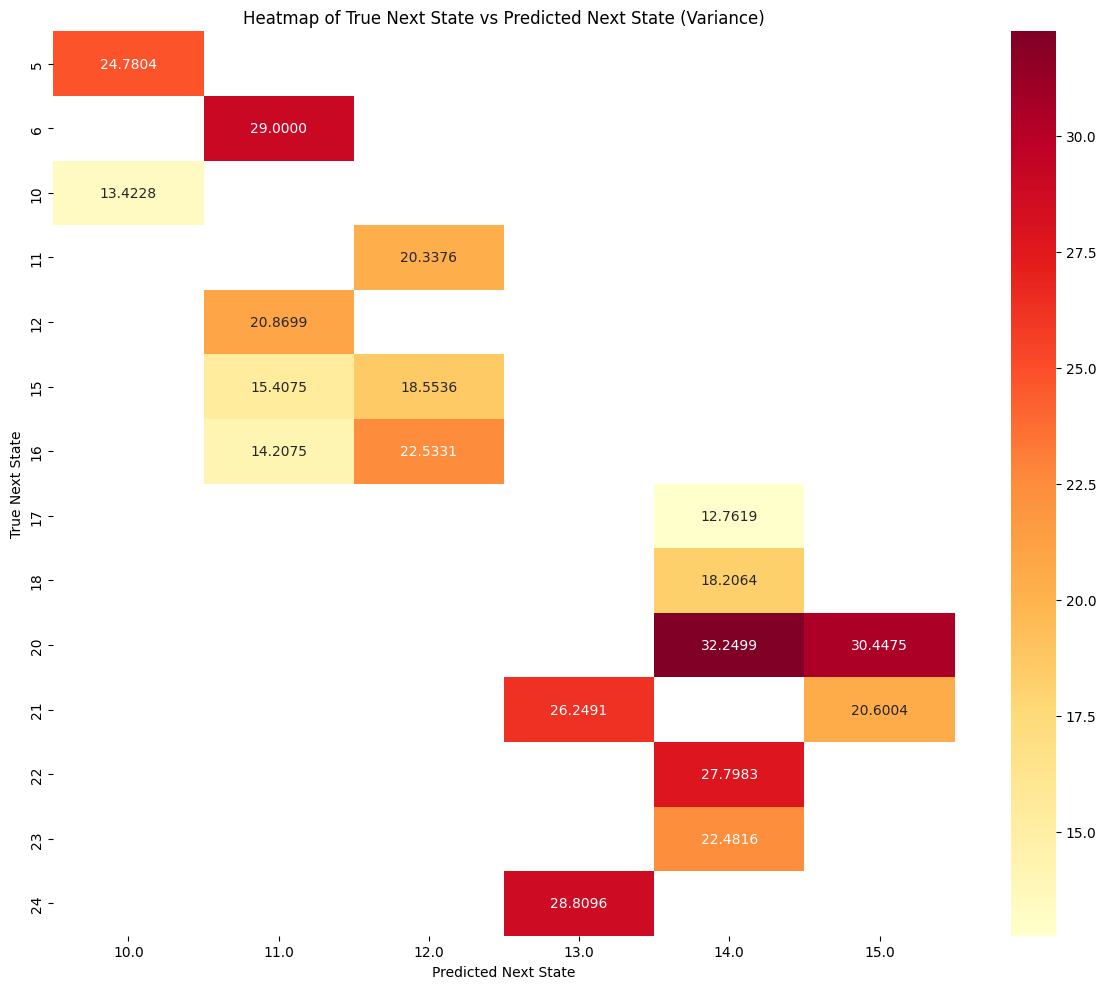

In [46]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [47]:
print(f"\nAvg Train Loss: {sum(total_loss_run5) / num_epochs}")
print('Final state_loss:',state_loss.item(),'\treward_loss:',reward_loss.item())
actual_next_s_idx = torch.argmax(next_states,1).squeeze()
predicted_next_s_idx = torch.argmax(predicted_next_states,1)
print('STATE RMSE',(torch.sum(
    (actual_next_s_idx-predicted_next_s_idx)**2)/len(next_states)
)**0.5)

data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run5)
}])
model_details = pd.concat([model_details,data], ignore_index=True)
# model_details


Avg Train Loss: 0.07757512632757425
Final state_loss: 0.032643720507621765 	reward_loss: 0.01824650540947914
STATE RMSE tensor(8.3326)


In [48]:
# lr: 1e-4
config["transition"]["hidden_dim"] = 128
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run6 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run6.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))
performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 526234
Correct preds: 4 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,2.1699
1,0,1,6,6.0,4.0139
2,5,0,10,10.0,2.2500
3,5,1,11,9.0,9.1451
4,6,0,10,9.0,3.6411
5,6,1,12,9.0,13.2139
6,10,0,15,14.0,9.3875
7,10,1,16,15.0,13.2200
8,11,0,15,15.0,3.5336
9,11,1,17,16.0,13.9100


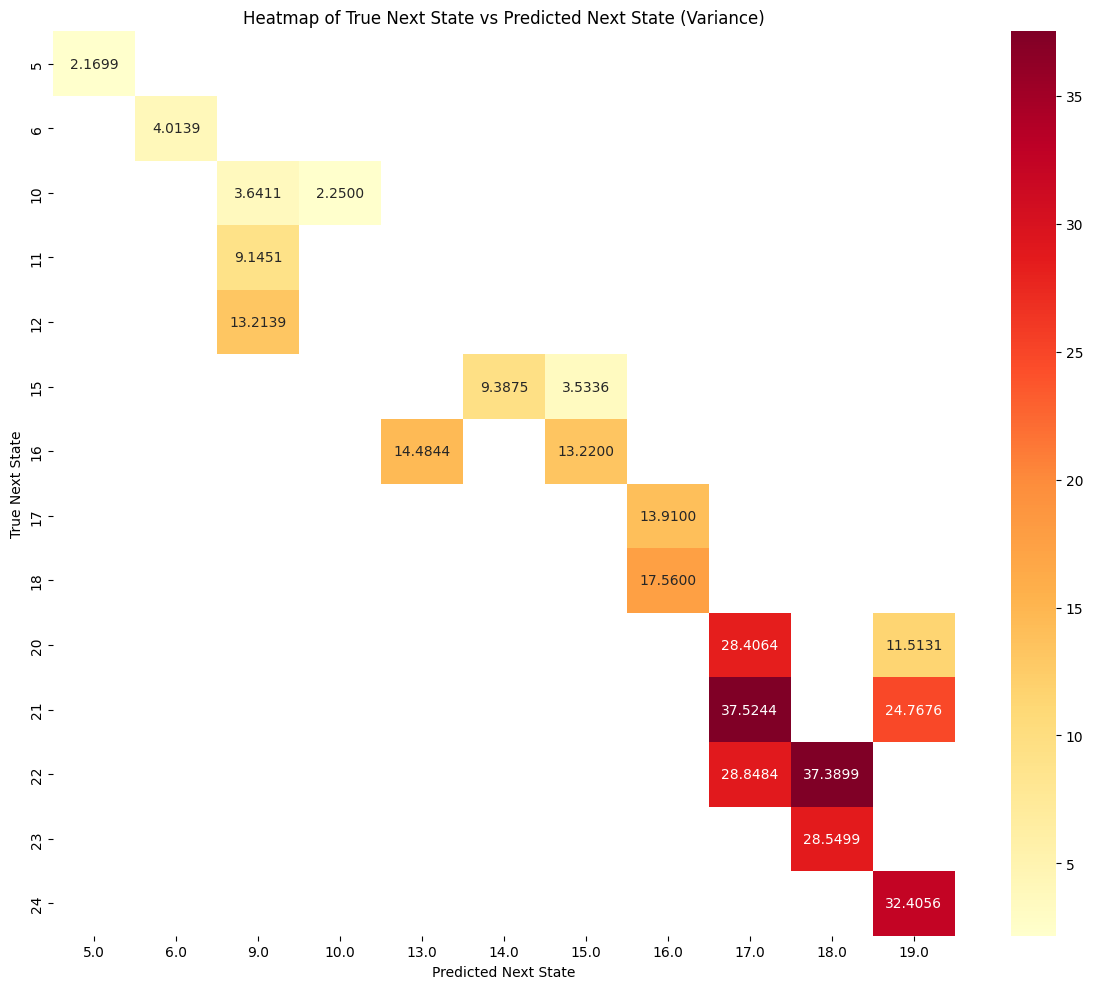

In [49]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [50]:
print(f"\nAvg Train Loss: {sum(total_loss_run6) / num_epochs}")
print('Final state_loss:',state_loss.item(),'\treward_loss:',reward_loss.item())
actual_next_s_idx = torch.argmax(next_states,1).squeeze()
predicted_next_s_idx = torch.argmax(predicted_next_states,1)
print('STATE RMSE',(torch.sum(
    (actual_next_s_idx-predicted_next_s_idx)**2)/len(next_states)
)**0.5)

data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run6)
}])
model_details = pd.concat([model_details,data], ignore_index=True)
model_details


Avg Train Loss: 0.05911750365048647
Final state_loss: 0.025438964366912842 	reward_loss: 0.01036681979894638
STATE RMSE tensor(6.7175)


,env,lr,context_len,hidden_dims,num_params,data_samples,train_epochs,avg_loss,best_loss
0,5,0.0010,3,32,34810,1000,100,NaN,0.026087
1,5,0.0010,3,64,134106,1000,100,NaN,0.015340
2,5,0.0010,3,128,526234,1000,100,NaN,0.010887
3,5,0.0001,3,32,34810,1000,100,NaN,0.068433
4,5,0.0001,3,64,134106,1000,100,NaN,0.049556
5,5,0.0001,3,128,526234,1000,100,NaN,0.035020


In [51]:
# lr: 1e-4
config["transition"]["hidden_dim"] = 256
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run7 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run7.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))
performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 2084634
Correct preds: 11 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,0.9900
1,0,1,6,6.0,0.9900
2,5,0,10,10.0,0.0000
3,5,1,11,11.0,2.5224
4,6,0,10,10.0,0.2475
5,6,1,12,11.0,5.2004
6,10,0,15,15.0,0.0000
7,10,1,16,16.0,1.1184
8,11,0,15,15.0,0.0000
9,11,1,17,16.0,1.9856


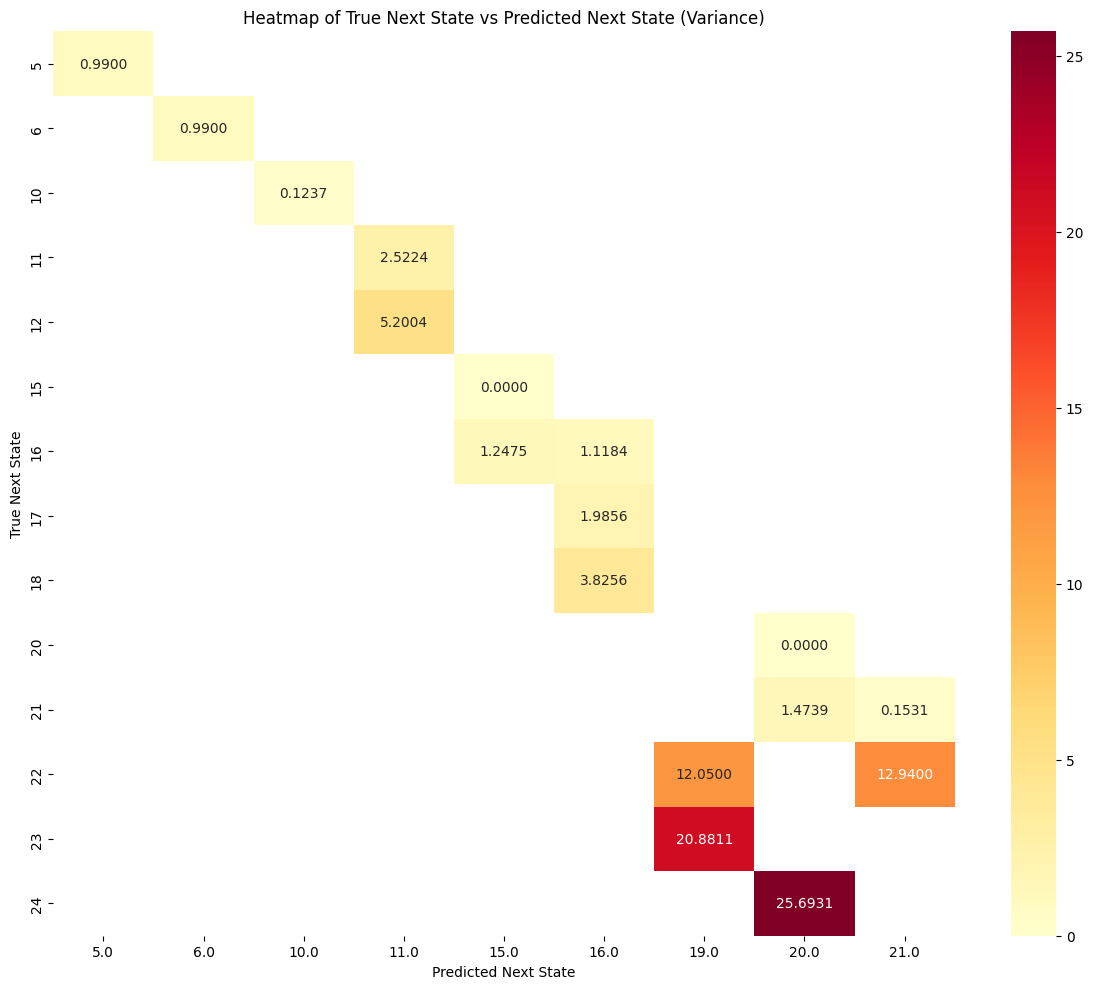

In [52]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [53]:
data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run7)
}])
model_details = pd.concat([model_details,data], ignore_index=True)


In [54]:
learning_rate = 1e-4
config["transition"]["hidden_dim"] = 512
transition_network = TransitionNetwork(
    config["transition"],
    obs_space,
    possible_actions,
    dropout=0.2, 
    max_steps=torch.max(timesteps).item()+1,
    device=torch.device('cpu')
    )

optimizer = torch.optim.Adam(transition_network.parameters(),learning_rate)

total_loss_run8 = []

for epoch in range(num_epochs):
    # print('\nEpoch',epoch)
    predicted_next_states, predicted_rewards, _ = transition_network.forward(timesteps, states, actions)
    # Compute loss
    state_loss = F.mse_loss(predicted_next_states, next_states.squeeze(1))
    reward_loss = F.mse_loss(predicted_rewards, rewards)
#     if (epoch+1)%10==0:
#         print(epoch,":\tstate_loss:",state_loss.item(),"\treward_loss:",reward_loss.item())
    loss = state_loss + reward_loss

    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss_run8.append(loss.item())


print('\nNumber of parameters:',
sum(p.numel() for p in transition_network.state_dict().values()))
performance = test_model(transition_network, test_transitions)
print('Correct preds:',sum(performance['true next_state']==performance['pred next_state']),
     '/',test_size)
performance


Number of parameters: 8298010
Correct preds: 17 / 20


,current_state,action,true next_state,pred next_state,variance
0,0,0,5,5.0,0.2475
1,0,1,6,6.0,0.0000
2,5,0,10,10.0,0.0000
3,5,1,11,11.0,0.5364
4,6,0,10,10.0,0.0000
5,6,1,12,12.0,0.7824
6,10,0,15,15.0,0.9900
7,10,1,16,16.0,0.3276
8,11,0,15,15.0,0.0000
9,11,1,17,17.0,2.4644


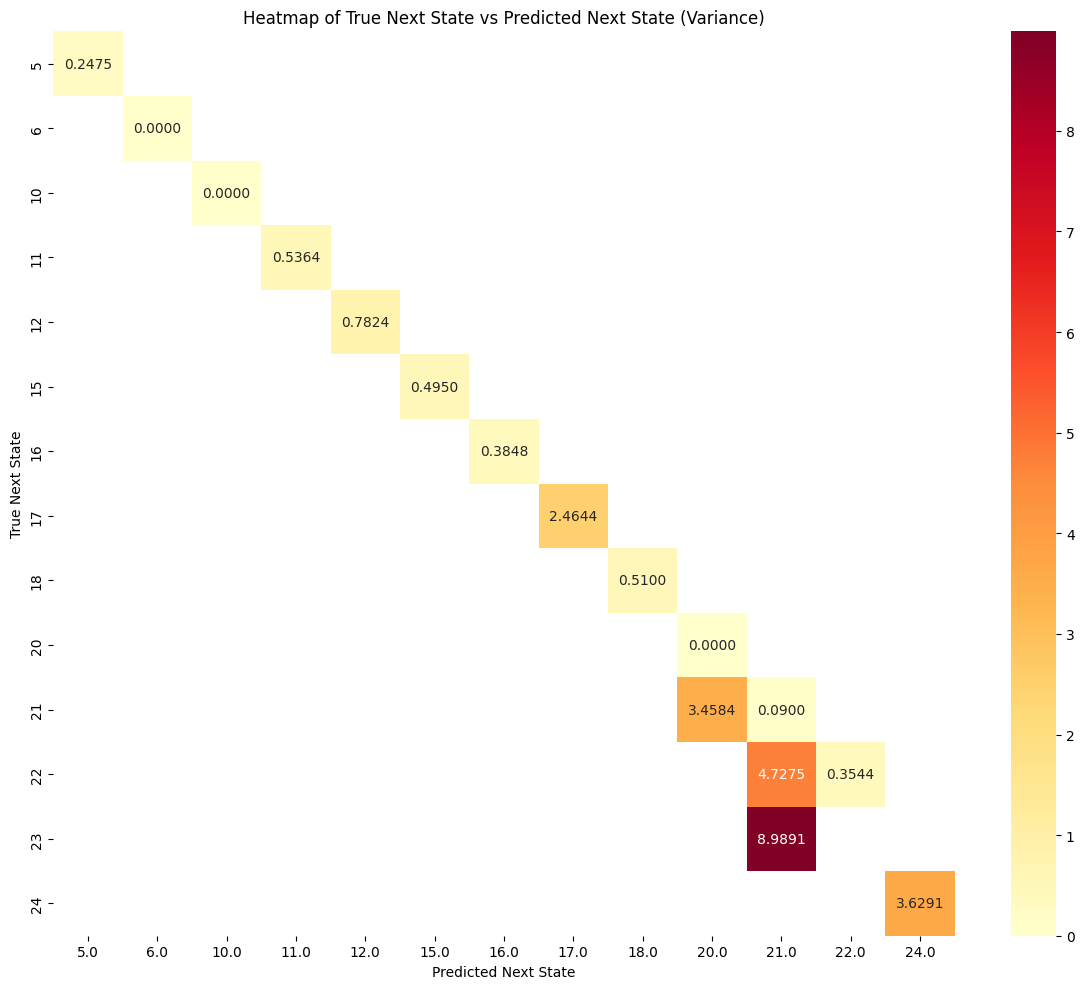

In [55]:
# Create a pivot table for the heatmap
pivot_table = performance.pivot_table(values='variance', index='true next_state', columns='pred next_state', aggfunc='mean')

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=True, cmap='YlOrRd', fmt='.4f')

plt.title('Heatmap of True Next State vs Predicted Next State (Variance)')
plt.xlabel('Predicted Next State')
plt.ylabel('True Next State')

plt.tight_layout()
plt.show()

In [56]:
data = pd.DataFrame(data=[{
    'env':int(config['experiment']['env']),
    'lr':learning_rate,
    'context_len':config['transition']['context_length'],
    'hidden_dims':config["transition"]["hidden_dim"],
    'num_params':sum(p.numel() for p in transition_network.state_dict().values()),
    'data_samples':time_limit,
    'train_epochs':num_epochs,
    'best_loss':min(total_loss_run8)
}])
model_details = pd.concat([model_details,data], ignore_index=True)


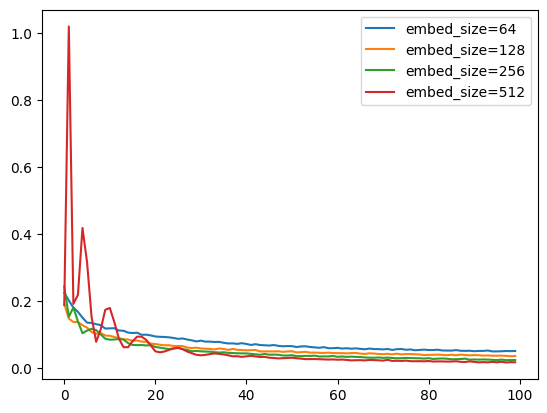

In [57]:

plt.plot(range(num_epochs), total_loss_run5, label='embed_size=64')
plt.plot(range(num_epochs), total_loss_run6, label='embed_size=128')
plt.plot(range(num_epochs), total_loss_run7, label='embed_size=256')
plt.plot(range(num_epochs), total_loss_run8, label='embed_size=512')
plt.legend()
# learning_rate = 1e-4

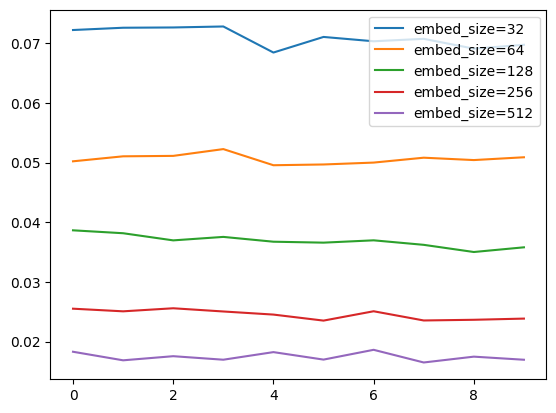

In [58]:
# zooming into the last 10 epochs
plt.plot(range(10), total_loss_run4[-10:], label='embed_size=32')
plt.plot(range(10), total_loss_run5[-10:], label='embed_size=64')
plt.plot(range(10), total_loss_run6[-10:], label='embed_size=128')
plt.plot(range(10), total_loss_run7[-10:], label='embed_size=256')
plt.plot(range(10), total_loss_run8[-10:], label='embed_size=512')
plt.legend()

In [59]:
model_details

,env,lr,context_len,hidden_dims,num_params,data_samples,train_epochs,avg_loss,best_loss
0,5,0.0010,3,32,34810,1000,100,NaN,0.026087
1,5,0.0010,3,64,134106,1000,100,NaN,0.015340
2,5,0.0010,3,128,526234,1000,100,NaN,0.010887
3,5,0.0001,3,32,34810,1000,100,NaN,0.068433
4,5,0.0001,3,64,134106,1000,100,NaN,0.049556
5,5,0.0001,3,128,526234,1000,100,NaN,0.035020
6,5,0.0001,3,256,2084634,1000,100,NaN,0.023529
7,5,0.0001,3,512,8298010,1000,100,NaN,0.016515


In [60]:
# model_details.to_csv('transition_model_experiments.csv',header=False,mode='a')